# PCA and KMean Clustering Using Scikit-Learn

### Load the Data

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv(r"train.csv")
df.head(3)

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING


In [3]:
test_df = pd.read_csv(r"test.csv")
test_df.head(3)

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.257178,-0.023285,-0.014654,-0.938404,-0.920091,-0.667683,-0.952501,-0.925249,-0.674302,-0.894088,...,-0.705974,0.006462,0.162920,-0.825886,0.271151,-0.720009,0.276801,-0.057978,2,STANDING
1,0.286027,-0.013163,-0.119083,-0.975415,-0.967458,-0.944958,-0.986799,-0.968401,-0.945823,-0.894088,...,-0.594944,-0.083495,0.017500,-0.434375,0.920593,-0.698091,0.281343,-0.083898,2,STANDING
2,0.275485,-0.026050,-0.118152,-0.993819,-0.969926,-0.962748,-0.994403,-0.970735,-0.963483,-0.939260,...,-0.640736,-0.034956,0.202302,0.064103,0.145068,-0.702771,0.280083,-0.079346,2,STANDING


In [4]:
print(f"df DataShape : {df.shape}\ntest_df DataShape : {test_df.shape}")

df DataShape : (7352, 563)
test_df DataShape : (2947, 563)


In [5]:
df.isnull().sum().sum()

np.int64(0)

In [6]:
# To check wether the train data is Balanced or not
df["Activity"].value_counts()

Activity
LAYING                1407
STANDING              1374
SITTING               1286
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
Name: count, dtype: int64

In [7]:
print(df.columns[:10].tolist())
print(df.columns[-5:].tolist())

['tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z', 'tBodyAcc-std()-X', 'tBodyAcc-std()-Y', 'tBodyAcc-std()-Z', 'tBodyAcc-mad()-X', 'tBodyAcc-mad()-Y', 'tBodyAcc-mad()-Z', 'tBodyAcc-max()-X']
['angle(X,gravityMean)', 'angle(Y,gravityMean)', 'angle(Z,gravityMean)', 'subject', 'Activity']


### PCA Analysis

In [8]:
print(df.iloc[:, :561].describe().round(2))
# it gives the min and max scale value. i.e here [-1 to 1] which means it is Normalised preprocessed data. also if [0 to 1] it is normalised.
# If it was standerdised data then it will be [-3 to 3] or [-5 to 5 ] or anything.

       tBodyAcc-mean()-X  tBodyAcc-mean()-Y  tBodyAcc-mean()-Z  \
count            7352.00            7352.00            7352.00   
mean                0.27              -0.02              -0.11   
std                 0.07               0.04               0.06   
min                -1.00              -1.00              -1.00   
25%                 0.26              -0.02              -0.12   
50%                 0.28              -0.02              -0.11   
75%                 0.29              -0.01              -0.10   
max                 1.00               1.00               1.00   

       tBodyAcc-std()-X  tBodyAcc-std()-Y  tBodyAcc-std()-Z  tBodyAcc-mad()-X  \
count           7352.00           7352.00           7352.00           7352.00   
mean              -0.61             -0.51             -0.60             -0.63   
std                0.45              0.50              0.42              0.42   
min               -1.00             -1.00             -1.00             -1.00   


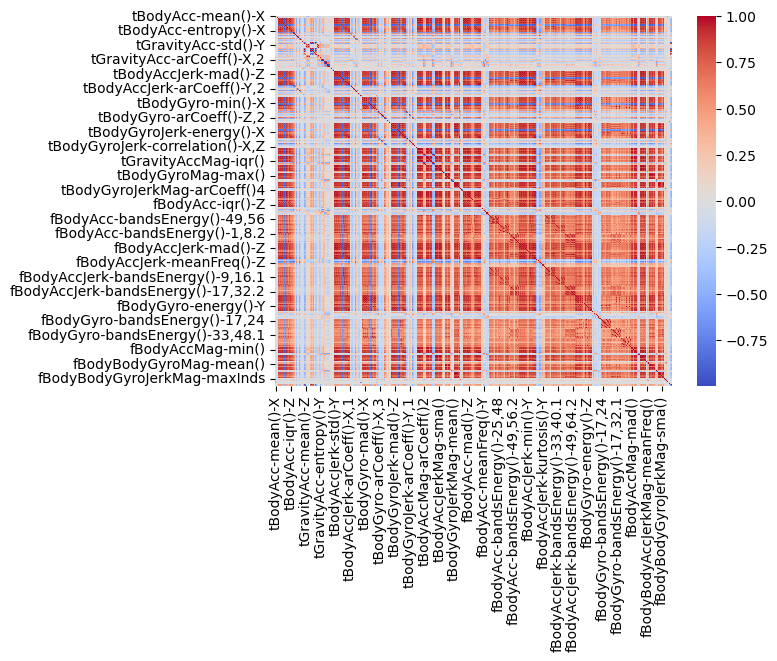

In [9]:
# Find the Correlation between the All the features.
# If the Correlation between the any features is high that means they behave same.
# That means we are going to combine those same behaving features to a single feature called "Principal Component".

import seaborn as sns
import matplotlib.pyplot as plt

corr = df.iloc[:, :561].corr()
sns.heatmap(corr, cmap='coolwarm')
plt.show()

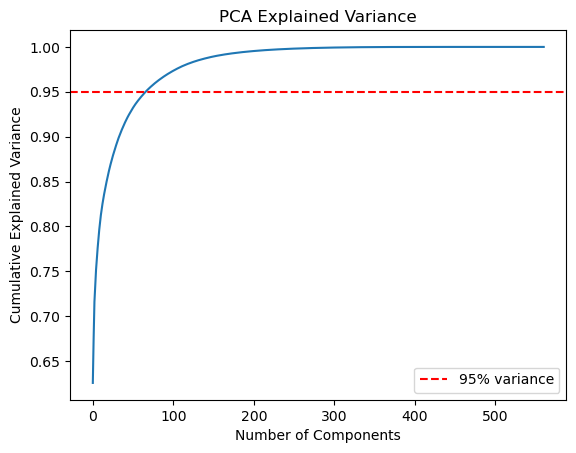

In [10]:
# importing PCA and computing the Cumulitive Variance.

from sklearn.decomposition import PCA
X = df.iloc[:, :561]        # iloc[:, :561] we are separating the last two columns/features ['subject', 'Activity'].
pca = PCA()
pca.fit(X)

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)  # explained_variance_ratio_ --> it returns array of [pc1 pc2 pc3]

plt.plot(cumulative_variance)     
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% variance')
plt.legend()
plt.title('PCA Explained Variance')
plt.show()

In [11]:
n_95 = np.argmax(cumulative_variance >= 0.95) + 1
n_99 = np.argmax(cumulative_variance >= 0.99) + 1

print(f"Components for 95% variance: {n_95}")
print(f"Components for 99% variance: {n_99}")

Components for 95% variance: 67
Components for 99% variance: 155


In [12]:
pca = PCA(n_components=67)
X_pca = pca.fit_transform(X)

print(X_pca.shape)

(7352, 67)


In [13]:
print(f"Now the X_pca is our Principal Componenet Analysis Features i.e (7352, 67). \nNow as we Reduced the number of columns from 561 to 67 based on Variance and Correlation between the each other features (columns).\nNow we can Use the clustering on them. ")


Now the X_pca is our Principal Componenet Analysis Features i.e (7352, 67). 
Now as we Reduced the number of columns from 561 to 67 based on Variance and Correlation between the each other features (columns).
Now we can Use the clustering on them. 


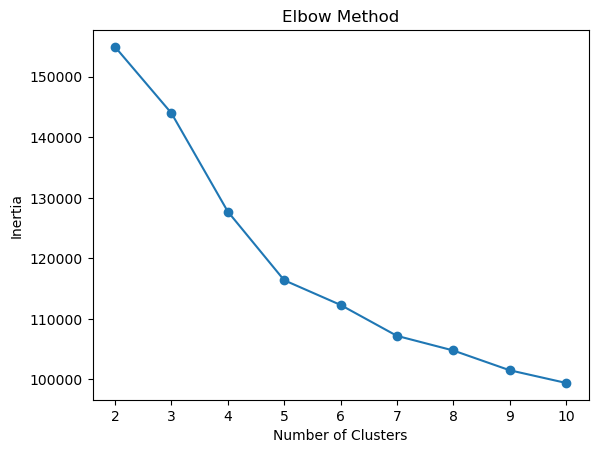

In [14]:
from sklearn.cluster import KMeans
inertia=[]
k_range = range(2,11)

for k in k_range:
    kmeans=KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_pca)
    inertia.append(kmeans.inertia_)

plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [15]:
print(f"From the Elbow method we came to know that k = 6 \n bcz its fit to the both domain knowledge and Elbow plot \n\n so We decided to work with the k=6")

From the Elbow method we came to know that k = 6 
 bcz its fit to the both domain knowledge and Elbow plot 

 so We decided to work with the k=6


In [16]:
kmeans=KMeans(n_clusters=6, random_state=42)
kmeans.fit(X_pca)
labels = kmeans.labels_

print(labels)
print(np.unique(labels,return_counts=True))

[0 0 0 ... 3 3 3]
(array([0, 1, 2, 3, 4, 5], dtype=int32), array([1587, 1016, 1258, 2038,  802,  651]))


In [17]:
print("clusters are Reasonably Balanced \nNo clusters have zero points \nArray([1587, 1016, 1258, 2038,  802,  651]) by adding all these values we get the Total rows = 7352 ")

clusters are Reasonably Balanced 
No clusters have zero points 
Array([1587, 1016, 1258, 2038,  802,  651]) by adding all these values we get the Total rows = 7352 


In [18]:
print("Now we need to Check How Good these clusters are? using the silhouette score: \n\nChecking the silhouette score now ")

Now we need to Check How Good these clusters are? using the silhouette score: 

Checking the silhouette score now 


In [19]:
from sklearn.metrics import silhouette_score
score = silhouette_score(X_pca, labels)
print(f"Silhouette score : {score:.4f}")

Silhouette score : 0.1731


In [23]:
print("Our silhouette score is very low, that may be because of the similar reading values in between the features \nso we can check the clustering values based on the k value to get the correct understanding \nand also need to check wether any overlapping is taken place?")

Our silhouette score is very low, that may be because of the similar reading values in between the features 
so we can check the clustering values based on the k value to get the correct understanding 
and also need to check wether any overlapping is taken place?


In [20]:
import pandas as pd
df["Cluster"] = labels
print(pd.crosstab(df["Activity"],df["Cluster"]))

Cluster               0    1    2    3    4    5
Activity                                        
LAYING                0    2    0   10  759  636
SITTING             812  415    0    1   43   15
STANDING            775  599    0    0    0    0
WALKING               0    0  373  853    0    0
WALKING_DOWNSTAIRS    0    0  726  260    0    0
WALKING_UPSTAIRS      0    0  159  914    0    0


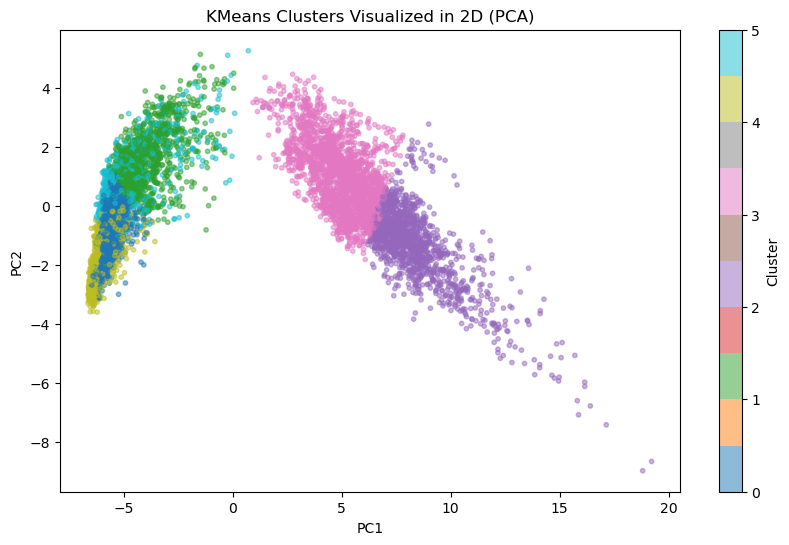

In [25]:
## we can visualize the clusters in 2D aslo for better understanding

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# we need to reduce the X_pca : 67 to 2 for the 2D visualization 
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_pca)

# Now we need to plot the clusters
plt.figure(figsize=(10,6))
scatter = plt.scatter(X_2d[:, 0],X_2d[:, 1],
                      c=labels,
                      cmap= 'tab10',
                      alpha=0.5,
                      s=10)
plt.colorbar(scatter, label='Cluster')
plt.title('KMeans Clusters Visualized in 2D (PCA)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

In [29]:
print("""
From the Above Image we can say that :
left side PC1 area : 
    - Blue, yellow, green, cyan dot cluster are tightly together.
    - These are static activities readings.
    - As the reading are very similar, thats why the silhouette score is low. 
    - This means no overlapping taken place!

""")


From the Above Image we can say that :
left side PC1 area : 
    - Blue, yellow, green, cyan dot cluster are tightly together.
    - These are static activities readings.
    - As the reading are very similar, thats why the silhouette score is low. 
    - This means no overlapping taken place!




In [30]:
import joblib
joblib.dump(kmeans, 'KMeans_model.pkl')
joblib.dump(pca, 'pca_model.pkl')

print("Models saved successfully")

Models saved successfully
